In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session


/kaggle/input/train.csv
/kaggle/input/description.md
/kaggle/input/sample_submission.csv.zip
/kaggle/input/test.csv.zip
/kaggle/input/train.csv.zip
/kaggle/input/test.csv
/kaggle/input/sample_submission.csv
/kaggle/input/playground-series-s3e18/train.csv
/kaggle/input/playground-series-s3e18/description.md
/kaggle/input/playground-series-s3e18/sample_submission.csv.zip
/kaggle/input/playground-series-s3e18/test.csv.zip
/kaggle/input/playground-series-s3e18/train.csv.zip
/kaggle/input/playground-series-s3e18/test.csv
/kaggle/input/playground-series-s3e18/sample_submission.csv


In [2]:
!pip install klib


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import klib
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder


In [4]:
df_train = pd.read_csv('/kaggle/input/playground-series-s3e18/train.csv')
df_test = pd.read_csv('/kaggle/input/playground-series-s3e18/test.csv')
sub = pd.read_csv('/kaggle/input/playground-series-s3e18/sample_submission.csv')


In [5]:
klib.missingval_plot(df_train)
klib.missingval_plot(df_test)
klib.missingval_plot(sub)


No missing values found in the dataset.
No missing values found in the dataset.
No missing values found in the dataset.


In [6]:
train = klib.data_cleaning(df_train)
test = klib.data_cleaning(df_test)


Shape of cleaned data: (13354, 38) - Remaining NAs: 0


Dropped rows: 0
     of which 0 duplicates. (Rows (first 150 shown): [])

Dropped columns: 0
     of which 0 single valued.     Columns: []
Dropped missing values: 0
Reduced memory by at least: 2.3 MB (-59.43%)

Shape of cleaned data: (1484, 32) - Remaining NAs: 0


Dropped rows: 0
     of which 0 duplicates. (Rows (first 150 shown): [])

Dropped columns: 0
     of which 0 single valued.     Columns: []
Dropped missing values: 0
Reduced memory by at least: 0.19 MB (-52.78%)



In [7]:
train=train.drop(['ec3','ec4', 'ec5', 'ec6'], axis = 1)
train


,id,bertz_ct,chi1,chi1n,chi1v,chi2n,chi2v,chi3v,chi4n,estate_vsa1,...,peoe_vsa7,peoe_vsa8,smr_vsa10,smr_vsa5,slog_p_vsa3,vsa_estate9,fr_coo,fr_coo2,ec1,ec2
0,3305,212.928436,6.270857,3.431698,4.045502,1.811731,2.272429,1.619489,0.828835,7.822697,...,0.000000,12.617665,22.655476,12.462663,13.825659,36.819859,0,0,1,1
1,8217,221.694351,4.060660,3.548618,3.548618,2.499652,2.499652,1.607504,0.883814,17.980452,...,12.132734,0.000000,17.650295,6.420822,9.589074,39.833332,2,2,1,0
2,12616,159.130753,4.414720,2.801636,2.801636,2.676274,2.676274,1.204209,0.361282,12.011147,...,0.000000,0.000000,5.969306,12.462663,11.215359,33.500000,1,1,1,1
3,10153,1239.282471,16.098661,10.151117,10.151117,11.008636,11.008636,7.914542,3.408511,5.969306,...,13.847474,6.420822,11.752550,69.031044,9.589074,73.500000,1,1,1,1
4,9564,574.170532,8.417121,5.143525,5.143525,3.478542,3.478542,2.264463,2.087653,5.969306,...,17.696186,6.076020,5.969306,57.332886,4.794537,39.166668,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13349,13123,527.123291,6.575387,4.381527,4.381527,3.159282,3.159282,2.023808,1.147945,0.000000,...,11.984273,12.487188,11.566490,12.462663,6.420822,39.666668,0,0,1,1
13350,3264,205.159454,6.702709,3.915975,3.915975,2.820365,2.820365,1.688578,0.846003,30.308453,...,17.696186,0.000000,11.876485,12.462663,9.589074,41.166668,1,1,1,1
13351,9845,134.264664,4.827186,2.722705,2.722705,1.812046,1.812046,1.018939,0.452598,12.011147,...,12.841643,0.000000,11.876485,12.462663,9.589074,35.666668,1,1,1,0
13352,10799,170.931015,5.125898,3.524374,3.524374,2.820365,2.820365,1.910460,1.068247,12.011147,...,19.386400,0.000000,12.255466,31.346146,9.589074,39.166668,1,1,1,1


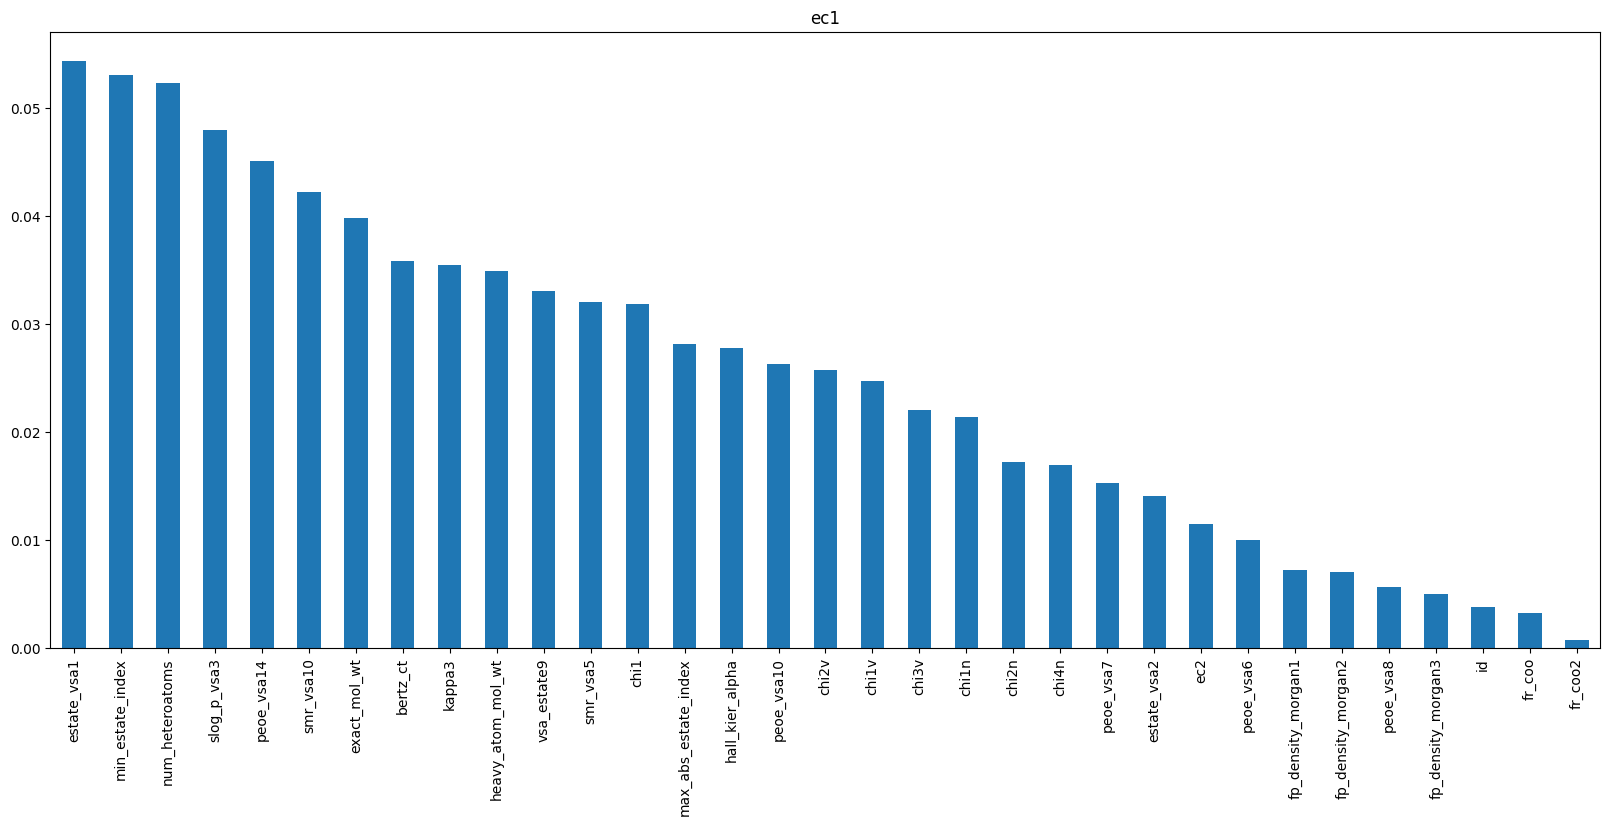

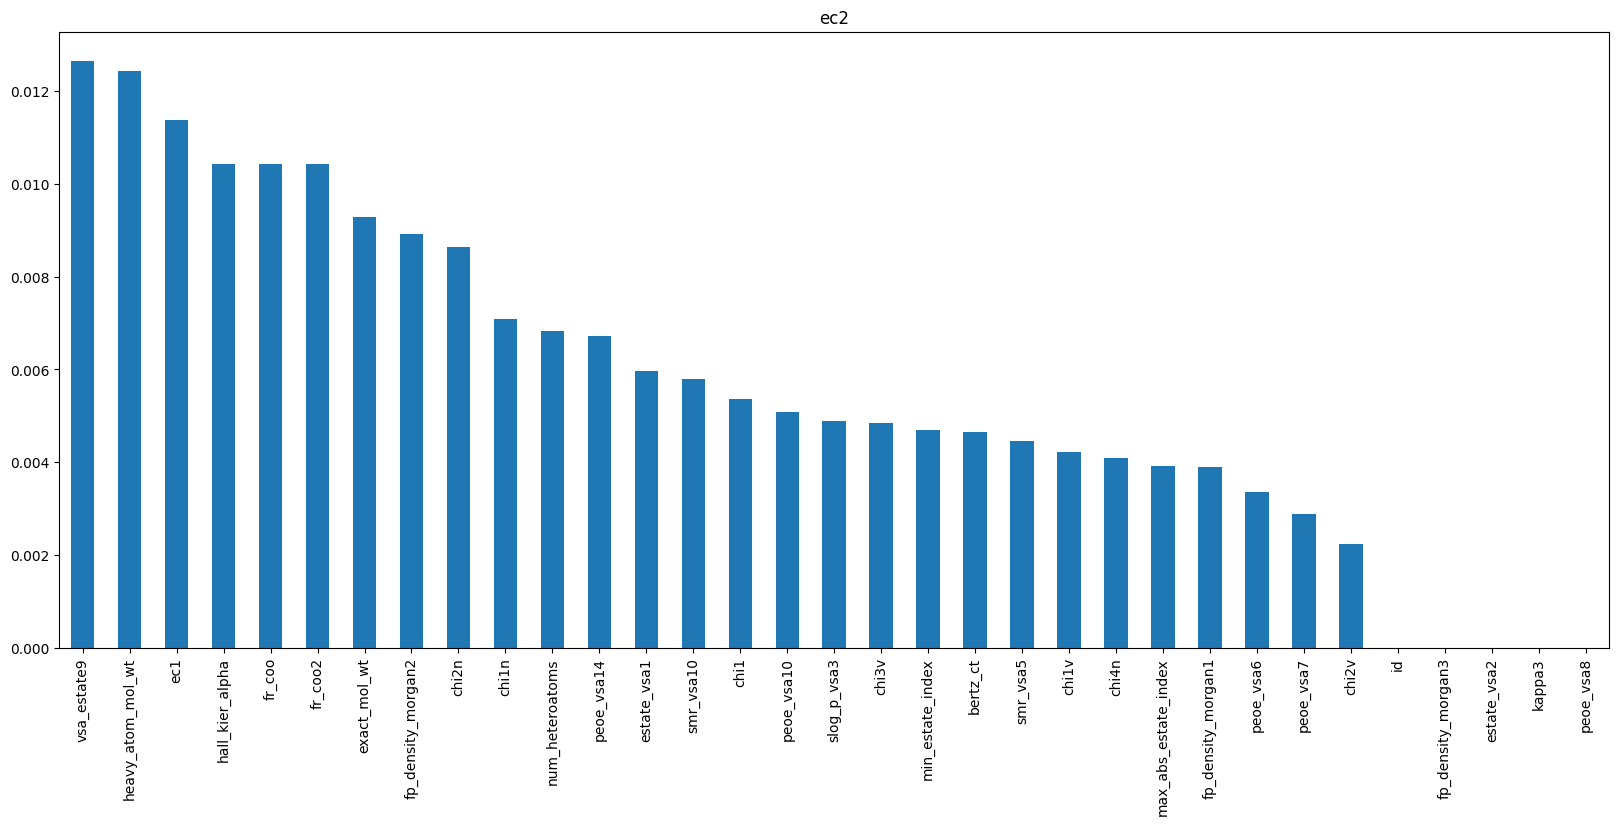

In [8]:
from sklearn.feature_selection import mutual_info_classif, SelectKBest
target = ['ec1','ec2']
dic = {}
for i in target:
    mutual_info=mutual_info_classif(train.drop([i],axis=1),train[i])
    mutual_info=pd.Series(mutual_info)
    mutual_info.index=train.drop([i],axis=1).columns
    columns=mutual_info.sort_values(ascending=False)
    columns.plot.bar(title=i,figsize=(20,8))
    plt.show()
    select_cols=SelectKBest(mutual_info_classif,k=10)
    select_cols.fit(train.drop([i],axis=1),train[i])
    dic[i]=train.drop([i],axis=1).columns[select_cols.get_support()]


In [9]:
mutual_info = mutual_info_classif(train.drop(['ec1'], axis = 1), train['ec1'])
mutual_info = pd.Series(mutual_info)
mutual_info.index = train.drop(['ec1'], axis = 1).columns
mutual_info = mutual_info.sort_values(ascending = False)
mutual_info


slog_p_vsa3             0.055201
min_estate_index        0.054416
estate_vsa1             0.050084
num_heteroatoms         0.045858
vsa_estate9             0.039059
peoe_vsa14              0.037505
heavy_atom_mol_wt       0.037160
smr_vsa10               0.036890
hall_kier_alpha         0.036808
smr_vsa5                0.035322
exact_mol_wt            0.034538
kappa3                  0.034002
bertz_ct                0.031755
peoe_vsa10              0.030686
chi1                    0.026364
max_abs_estate_index    0.025850
chi3v                   0.025431
chi2v                   0.023320
chi1v                   0.022841
peoe_vsa7               0.022282
chi2n                   0.022203
chi4n                   0.021518
chi1n                   0.017019
peoe_vsa6               0.016906
fp_density_morgan1      0.016757
estate_vsa2             0.012867
fp_density_morgan3      0.012118
ec2                     0.012000
peoe_vsa8               0.006671
fp_density_morgan2      0.006001
fr_coo    

In [10]:
mutual_info.index[0:round(len(mutual_info)/2)]


Index(['slog_p_vsa3', 'min_estate_index', 'estate_vsa1', 'num_heteroatoms',
       'vsa_estate9', 'peoe_vsa14', 'heavy_atom_mol_wt', 'smr_vsa10',
       'hall_kier_alpha', 'smr_vsa5', 'exact_mol_wt', 'kappa3', 'bertz_ct',
       'peoe_vsa10', 'chi1', 'max_abs_estate_index'],
      dtype='object')

In [11]:
test


,id,bertz_ct,chi1,chi1n,chi1v,chi2n,chi2v,chi3v,chi4n,estate_vsa1,...,peoe_vsa14,peoe_vsa6,peoe_vsa7,peoe_vsa8,smr_vsa10,smr_vsa5,slog_p_vsa3,vsa_estate9,fr_coo,fr_coo2
0,1377,221.263870,7.413591,5.874959,5.874959,2.861666,2.861666,1.786050,1.058931,5.969306,...,5.969306,24.304081,6.076020,5.563451,5.969306,0.000000,11.215359,55.666668,1,1
1,5485,124.934334,6.270857,3.633936,3.633936,2.571553,2.571553,1.539558,0.835261,6.103966,...,91.536491,0.000000,0.000000,0.000000,17.744066,37.629631,4.794537,29.776814,0,0
2,8753,635.074646,8.702708,5.790466,5.790466,4.516427,4.516427,3.710047,2.299833,26.502851,...,0.000000,0.000000,0.000000,0.000000,11.163877,24.539801,4.736863,53.217316,0,0
3,10746,155.036987,4.536581,2.688080,2.688080,1.812046,1.812046,0.835979,0.592466,17.980452,...,11.938611,0.000000,6.420822,0.000000,11.938611,19.386400,9.589074,40.083332,2,2
4,7554,313.333130,7.430428,4.046610,4.451852,2.725738,3.181080,2.093778,1.275017,24.601927,...,0.000000,0.000000,12.132734,0.000000,16.864286,12.207932,4.736863,44.716240,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1479,9737,277.172791,5.947265,3.663903,3.663903,2.471029,2.471029,1.286450,0.895230,5.969306,...,5.969306,0.000000,12.132734,12.132734,11.876485,12.462663,9.589074,39.000000,1,1
1480,3126,371.629852,8.540913,6.391202,6.391202,4.752571,5.439976,2.364598,1.824731,17.353601,...,5.969306,0.000000,6.420822,6.420822,11.752550,24.856655,9.589074,39.166668,1,1
1481,4026,2031.710815,26.948946,17.525227,23.032011,14.350623,19.738680,12.804626,5.276218,84.554970,...,23.468092,55.941196,5.563451,37.098999,69.141350,63.753708,50.697491,117.854591,0,0
1482,10892,202.214996,5.701907,3.043604,3.456598,2.422955,3.662308,1.709859,0.665697,36.992054,...,5.969306,0.000000,0.000000,0.000000,11.752550,24.415865,9.589074,43.000000,1,1


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


<Axes: title={'center': 'Feature-correlation (pearson)'}>

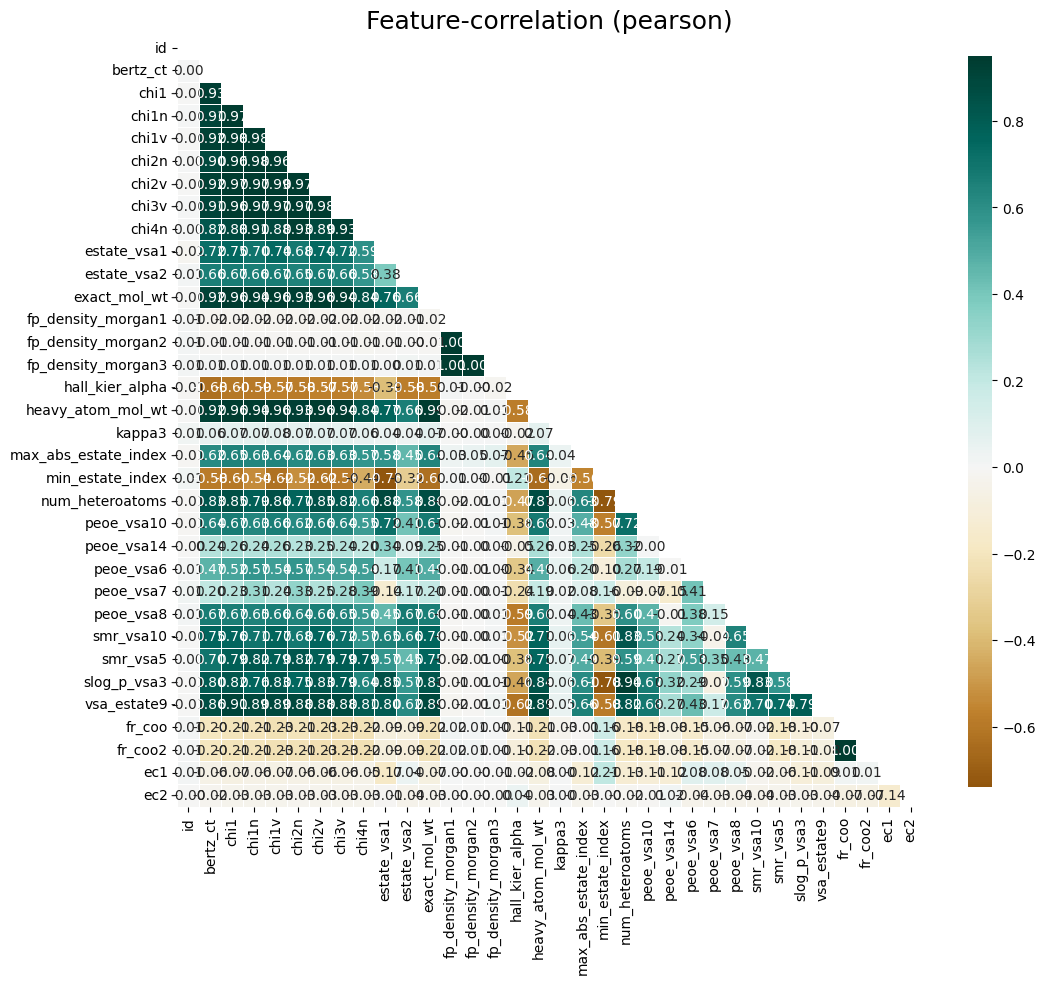

In [12]:
klib.corr_plot(train)


In [13]:
train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13354 entries, 0 to 13353
Data columns (total 34 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    13354 non-null  int16  
 1   bertz_ct              13354 non-null  float32
 2   chi1                  13354 non-null  float32
 3   chi1n                 13354 non-null  float32
 4   chi1v                 13354 non-null  float32
 5   chi2n                 13354 non-null  float32
 6   chi2v                 13354 non-null  float32
 7   chi3v                 13354 non-null  float32
 8   chi4n                 13354 non-null  float32
 9   estate_vsa1           13354 non-null  float32
 10  estate_vsa2           13354 non-null  float32
 11  exact_mol_wt          13354 non-null  float32
 12  fp_density_morgan1    13354 non-null  float32
 13  fp_density_morgan2    13354 non-null  float32
 14  fp_density_morgan3    13354 non-null  float32
 15  hall_kier_alpha    

In [14]:
train.describe().T


,count,mean,std,min,25%,50%,75%,max
id,13354.0,7430.046054,4280.726674,0.000000,3725.250000,7424.500000,11138.750000,14837.000000
bertz_ct,13354.0,515.344116,541.589966,0.000000,149.874527,292.455292,652.281494,4069.959717
chi1,13354.0,9.135106,6.811704,0.000000,4.680739,6.494089,11.170341,69.551170
chi1n,13354.0,5.854335,4.641641,0.000000,2.854294,4.059093,7.486483,50.174587
chi1v,13354.0,6.741385,5.859601,0.000000,2.932842,4.392859,8.527860,53.431953
chi2n,13354.0,4.434309,3.759896,0.000000,1.949719,2.970427,5.788793,32.195370
chi2v,13354.0,5.251853,4.914249,0.000000,2.037238,3.261677,6.621896,34.579311
chi3v,13354.0,3.416553,3.425806,0.000000,1.162568,1.951087,4.502070,22.589275
chi4n,13354.0,1.772391,1.860332,0.000000,0.508512,1.077096,2.540348,16.072809
estate_vsa1,13354.0,29.207582,31.755650,0.000000,5.969306,17.353601,44.876560,363.705963


In [15]:
df_train_test = pd.concat([train, test])
df_train_test = df_train_test.drop(['ec1', 'ec2', 'id'], axis = 1)


In [16]:
col = df_train_test.columns
segments = ['low', 'low-med', 'high-med', 'high']
for col_name in col:
    df_train_test[col_name+'_class'] = pd.cut(df_train_test[col_name], 4, labels = segments )


In [17]:
df_train_test = pd.get_dummies(df_train_test, columns = df_train_test.select_dtypes('category').columns)
df_train_test


,bertz_ct,chi1,chi1n,chi1v,chi2n,chi2v,chi3v,chi4n,estate_vsa1,estate_vsa2,...,vsa_estate9_class_high-med,vsa_estate9_class_high,fr_coo_class_low,fr_coo_class_low-med,fr_coo_class_high-med,fr_coo_class_high,fr_coo2_class_low,fr_coo2_class_low-med,fr_coo2_class_high-med,fr_coo2_class_high
0,212.928436,6.270857,3.431698,4.045502,1.811731,2.272429,1.619489,0.828835,7.822697,6.420822,...,False,False,True,False,False,False,True,False,False,False
1,221.694351,4.060660,3.548618,3.548618,2.499652,2.499652,1.607504,0.883814,17.980452,0.000000,...,False,False,True,False,False,False,True,False,False,False
2,159.130753,4.414720,2.801636,2.801636,2.676274,2.676274,1.204209,0.361282,12.011147,0.000000,...,False,False,True,False,False,False,True,False,False,False
3,1239.282471,16.098661,10.151117,10.151117,11.008636,11.008636,7.914542,3.408511,5.969306,30.650627,...,False,False,True,False,False,False,True,False,False,False
4,574.170532,8.417121,5.143525,5.143525,3.478542,3.478542,2.264463,2.087653,5.969306,24.498335,...,False,False,True,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1479,277.172791,5.947265,3.663903,3.663903,2.471029,2.471029,1.286450,0.895230,5.969306,12.451936,...,False,False,True,False,False,False,True,False,False,False
1480,371.629852,8.540913,6.391202,6.391202,4.752571,5.439976,2.364598,1.824731,17.353601,12.356394,...,False,False,True,False,False,False,True,False,False,False
1481,2031.710815,26.948946,17.525227,23.032011,14.350623,19.738680,12.804626,5.276218,84.554970,48.028175,...,False,False,True,False,False,False,True,False,False,False
1482,202.214996,5.701907,3.043604,3.456598,2.422955,3.662308,1.709859,0.665697,36.992054,0.000000,...,False,False,True,False,False,False,True,False,False,False


In [18]:
scaler = MinMaxScaler(feature_range = (0,1))
df_train_test_scale = scaler.fit_transform(df_train_test)
df_train_test_scale = pd.DataFrame(df_train_test_scale)
df_train_test_scale.columns = df_train_test.columns
df_train_test_scale


,bertz_ct,chi1,chi1n,chi1v,chi2n,chi2v,chi3v,chi4n,estate_vsa1,estate_vsa2,...,vsa_estate9_class_high-med,vsa_estate9_class_high,fr_coo_class_low,fr_coo_class_low-med,fr_coo_class_high-med,fr_coo_class_high,fr_coo2_class_low,fr_coo2_class_low-med,fr_coo2_class_high-med,fr_coo2_class_high
0,0.052317,0.090162,0.068395,0.075713,0.056273,0.065716,0.070779,0.051568,0.021508,0.064249,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.054471,0.058384,0.070725,0.066414,0.077640,0.072287,0.070255,0.054988,0.049437,0.000000,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.039099,0.063474,0.055838,0.052434,0.083126,0.077395,0.052630,0.022478,0.033024,0.000000,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.304495,0.231465,0.202316,0.189982,0.341932,0.318359,0.345903,0.212067,0.016412,0.306701,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.141075,0.121021,0.102513,0.096263,0.108045,0.100596,0.098968,0.129887,0.016412,0.245139,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14833,0.068102,0.085509,0.073023,0.068571,0.076751,0.071460,0.056224,0.055698,0.016412,0.124599,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
14834,0.091310,0.122800,0.127379,0.119614,0.147617,0.157319,0.103344,0.113529,0.047713,0.123643,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
14835,0.499197,0.387469,0.349285,0.431053,0.445736,0.570823,0.559622,0.328270,0.232482,0.480587,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
14836,0.049685,0.081981,0.060660,0.064692,0.075258,0.105910,0.074729,0.041418,0.101709,0.000000,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [19]:
train = df_train_test_scale[0:len(train)]
test = df_train_test_scale[len(train):len(df_train_test)]


In [20]:
train


,bertz_ct,chi1,chi1n,chi1v,chi2n,chi2v,chi3v,chi4n,estate_vsa1,estate_vsa2,...,vsa_estate9_class_high-med,vsa_estate9_class_high,fr_coo_class_low,fr_coo_class_low-med,fr_coo_class_high-med,fr_coo_class_high,fr_coo2_class_low,fr_coo2_class_low-med,fr_coo2_class_high-med,fr_coo2_class_high
0,0.052317,0.090162,0.068395,0.075713,0.056273,0.065716,0.070779,0.051568,0.021508,0.064249,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.054471,0.058384,0.070725,0.066414,0.077640,0.072287,0.070255,0.054988,0.049437,0.000000,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.039099,0.063474,0.055838,0.052434,0.083126,0.077395,0.052630,0.022478,0.033024,0.000000,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.304495,0.231465,0.202316,0.189982,0.341932,0.318359,0.345903,0.212067,0.016412,0.306701,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.141075,0.121021,0.102513,0.096263,0.108045,0.100596,0.098968,0.129887,0.016412,0.245139,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13349,0.129516,0.094540,0.087326,0.082002,0.098128,0.091363,0.088450,0.071422,0.000000,0.224107,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
13350,0.050408,0.096371,0.078047,0.073289,0.087602,0.081562,0.073799,0.052636,0.083332,0.121781,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
13351,0.032989,0.069405,0.054265,0.050956,0.056283,0.052403,0.044532,0.028159,0.033024,0.123251,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
13352,0.041998,0.073700,0.070242,0.065960,0.087602,0.081562,0.083496,0.066463,0.033024,0.132222,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [21]:
from sklearn.ensemble import GradientBoostingClassifier, VotingClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score, train_test_split, cross_val_score
from sklearn import metrics
from xgboost import XGBClassifier
import xgboost as xgb
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

from sklearn.tree import DecisionTreeClassifier, ExtraTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier, HistGradientBoostingClassifier, AdaBoostClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.neighbors import KNeighborsClassifier, RadiusNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import SGDClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.metrics import roc_auc_score, precision_score


ModuleNotFoundError: No module named 'sklearn.utils._metadata_requests'

In [22]:
y_train = df_train[['EC1','EC2']]
X_train = train
X_test = test
print(f"X_train shape is = {X_train.shape}" )
print(f"y_train shape is = {y_train.shape}" )
print(f"Test shape is = {X_test.shape}" )


X_train shape is = (13354, 155)
y_train shape is = (13354, 2)
Test shape is = (1484, 155)


In [23]:
y_train.head(5)


,EC1,EC2
0,1,1
1,1,0
2,1,1
3,1,1
4,1,0


In [24]:
#X_tr, X_te, y_tr, y_te = train_test_split(X_train, y_train, random_state =43, test_size = 0.2)


In [25]:
kfold = KFold (n_splits=5, shuffle=True, random_state=42)


NameError: name 'KFold' is not defined

In [26]:
#print(f"X_tr shape is = {X_tr.shape}" )
#print(f"y_tr shape is = {y_tr.shape}" )
#print(f"X_te shape is = {X_te.shape}" )
#print(f"y_te shape is = {y_te.shape}" )


In [27]:
xgb = XGBClassifier(n_estimators=2500, random_state = 46, learning_rate=0.009,max_depth=7, max_leaves=15, tree_method="gpu_hist")
gb = GradientBoostingClassifier(random_state = 44, learning_rate=0.009, n_estimators=500, max_depth=10,
                                min_samples_split=20, min_samples_leaf=15)


In [28]:
#model = [xgb,gb]
#for model in model:
#    model.fit(X_tr, y_tr)
#    #y_pred = model.predict_proba(X_test)
#    y_pred = model.predict_proba(X_te)[:,1]
#    ROC = metrics.roc_auc_score(y_te, y_pred)
#    print(model, '\n', ROC, '\n')


In [29]:
xgb_clf = MultiOutputClassifier(xgb)


NameError: name 'MultiOutputClassifier' is not defined

In [30]:
for fn, (trn_idx, val_idx) in enumerate(kfold.split(X_train, y_train)):
    print('Starting fold:', fn)
    X_train_kf, X_val_kf = X_train.iloc[trn_idx], X_train.iloc[val_idx]
    y_train_kf, y_val_kf = y_train.iloc[trn_idx], y_train.iloc[val_idx]
    print(f"X_train_kf shape is = {X_train_kf.shape}" )
    print(X_train_kf.head(10))
    print(f"X_val_kf shape is = {X_val_kf.shape}" )
    print(X_val_kf.head(10))
    print(f"y_train_kf shape is = {y_train_kf.shape}" )
    print(y_train_kf.head(10))
    print(f"y_val_kf shape is = {y_val_kf.shape}" )
    print(y_val_kf.head(10))


NameError: name 'kfold' is not defined

In [31]:
oof_preds_xgb = np.zeros(y_train.shape)
oof_preds_lgbm = np.zeros(y_train.shape)
oof_losses_xgb = []
oof_losses_lgbm = []
for fn, (trn_idx, val_idx) in enumerate(kfold.split(X_train, y_train)):
    print('Starting fold:', fn)
    X_train_kf, X_val_kf = X_train.iloc[trn_idx], X_train.iloc[val_idx]
    y_train_kf, y_val_kf = y_train.iloc[trn_idx], y_train.iloc[val_idx]
    xgb_clf.fit(X_train_kf, y_train_kf)

    val_preds_xgb = xgb_clf.predict_proba(X_val_kf)
    
    qual_pred = metrics.mean_squared_error(np.ravel(np.array(val_preds_xgb)[:, :, 1].T), np.ravel(y_val_kf))
    #oof_losses_xgb.append(loss_xgb)
    #preds_xgb = xgb_clf.predict_proba(X_test)
    #preds_xgb = np.array(preds_xgb)[:, :, 1].T
    #test_preds_xgb += preds_xgb / n_splits
    
    #print("overall_train_loss",overall_train_loss)
    #print("overall_valid_loss",overall_valid_loss)
    print('\n metrics.mean_squared_error', qual_pred, '\n')


NameError: name 'kfold' is not defined

In [32]:
# как понять predict_proba при использовании MultiOutputClassifier https://datascience.stackexchange.com/questions/22762/understanding-predict-proba-from-multioutputclassifier


In [33]:
val_preds_xgb


NameError: name 'val_preds_xgb' is not defined

In [34]:
zzz = np.array(val_preds_xgb)[:, :, 1].T
zzz


NameError: name 'val_preds_xgb' is not defined

In [35]:
metrics.mean_squared_error(np.ravel(np.array(val_preds_xgb)[:, :, 1].T), np.ravel(y_val_kf))


NameError: name 'val_preds_xgb' is not defined

In [36]:
np.ravel(np.array(val_preds_xgb)[:, :, 1].T)


NameError: name 'val_preds_xgb' is not defined

In [37]:
np.ravel(y_val_kf)


NameError: name 'y_val_kf' is not defined

In [38]:
np.shape(np.ravel(y_val_kf))


NameError: name 'y_val_kf' is not defined

In [39]:
y_val_kf.shape


NameError: name 'y_val_kf' is not defined

In [40]:
#xgb_classifier.fit(X_tr, y_tr)


In [41]:
#xgb_clf = xgb_classifier
#train_preds_xgb = xgb_clf.predict_proba(X_train)
#train_preds_xgb = np.array(train_preds_xgb)[:, :, 1].T


In [42]:
#train_preds_xgb


In [43]:
#model = RandomForestClassifier(n_estimators=1000)
model = xgb_clf


NameError: name 'xgb_clf' is not defined

In [44]:
#model.fit(X_tr, y_tr)


In [45]:
#y_pred = model.predict_proba(X_te)


In [46]:
#model.predict(X_te)


In [47]:
prediction = model.predict(X_test)


NameError: name 'model' is not defined

In [48]:
prediction


NameError: name 'prediction' is not defined

In [49]:
predictions = pd.DataFrame(prediction, columns=["EC1","EC2"])

results = pd.concat([sub['id'],predictions],axis=1)

results.to_csv("submission.csv",index=False)


NameError: name 'prediction' is not defined